In [ ]:
# from sklearn.datasets import make_regression
# import matplotlib.pyplot as plt
# import numpy as np

In [18]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [19]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

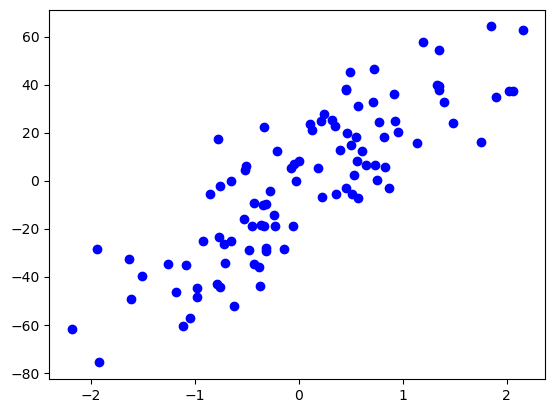

In [20]:
plt.scatter(X, y, color='blue', label='Data points')

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.coef_

array([28.12597332])

In [24]:
lr.intercept_

np.float64(-2.271014426178382)

In [25]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6345158782661013

In [26]:
np.mean(cross_val_score(lr, X, y, scoring='r2', cv=10))

np.float64(0.6375011587464419)

# Only b

In [15]:
class GradientDescentRegressor:
    def __init__(self, epochs, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 27.82
        self.b = -120

    def fit(self, X, y):
        # Calculate the b using GD
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m * X.ravel() - self.b)
            self.b = self.b - (self.learning_rate * loss_slope)
            print(loss_slope, self.b)
        print(self.b)

    def predict(self, X):
        pass

In [16]:
gd = GradientDescentRegressor(epochs=100, learning_rate=0.001)

In [17]:
gd.fit(X_train, y_train)

-18839.117141215604 -101.16088285878439
-15824.858398621107 -85.33602446016329
-13292.88105484173 -72.04314340532156
-11166.020086067056 -60.8771233192545
-9379.456872296325 -51.49766644695818
-7878.743772728914 -43.61892267422926
-6618.144769092287 -37.00077790513697
-5559.241606037521 -31.44153629909945
-4669.762949071517 -26.771773350027935
-3922.600877220075 -22.84917247280786
-3294.9847368648634 -19.554187735943
-2767.787178966485 -16.786400556976513
-2324.9412303318477 -14.461459326644665
-1952.9506334787516 -12.508508693165913
-1640.4785321221516 -10.868030161043762
-1378.0019669826072 -9.490028194061155
-1157.52165226539 -8.332506541795766
-972.3181879029278 -7.3601883538928385
-816.7472778384592 -6.543441076054379
-686.0677133843058 -5.8573733626700735
-576.2968792428171 -5.281076483427256
-484.0893785639663 -4.79698710486329
-406.63507799373184 -4.390352026869558
-341.5734655147345 -4.0487785613548235
-286.921711032377 -3.7618568503224465
-241.01423726719662 -3.52084261305525

# With b and m

In [27]:
class GradientDescentRegressor:
    def __init__(self, epochs, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 100
        self.b = -120

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            self.m = self.m - (self.learning_rate * loss_slope_m)
            self.b = self.b - (self.learning_rate * loss_slope_b)
        print(self.m, self.b)
    
    def predict(self, X):
        return self.m * X + self.b

In [28]:
gd = GradientDescentRegressor(epochs=75, learning_rate=0.001)

In [29]:
gd.fit(X_train, y_train)

28.126635774053963 -2.2715196051327213


In [30]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6345132562305686

In [31]:
gd.predict(X_test)

array([[ 21.09906119],
       [ 18.03492861],
       [ 18.23745201],
       [ -8.10356905],
       [ 15.72626385],
       [ 58.21151889],
       [-15.03404756],
       [-11.33177438],
       [-15.81087809],
       [ -8.80887745],
       [-23.5761306 ],
       [ 14.78134062],
       [ 12.70135429],
       [-23.89041186],
       [-22.30867229],
       [-16.67137534],
       [ 24.52839995],
       [-16.98636893],
       [ -3.88971212],
       [-12.02040248]])

In [ ]:
# np.mean(cross_val_score(gd, X, y, scoring='r2', cv=10))